In [1]:
from data.PAM_data import data_split_PAM, load_PAM_loco_data, make_loaders_PAM
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

In [2]:
def load_folds_results(base_dir, dataset_name, folds = 4):
    all_folds = {}
    for idx in range(1, folds+1):
        json_path = Path(base_dir) / f"{dataset_name}_fold{idx}_results.json"   
        with open(json_path, "r") as f:
            all_folds[idx] = json.load(f)  
    return all_folds

In [3]:
def plot_val_curves(results, fold_idx):
    runs = results["runs"]
    all_histories = {}
    for seed_name in runs:
        all_histories[seed_name] = pd.DataFrame(runs[seed_name]["history"])
    min_epochs = min(len(df) for df in all_histories.values())
    epochs = np.arange(1, min_epochs+1)
    val_loss_all= np.array([df["val_loss"].values[:min_epochs] for df in all_histories.values()])
    
    val_loss_mean = val_loss_all.mean(axis = 0)
    val_loss_std = val_loss_all.std(axis = 0)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    # LOSS
    axes[0].plot(epochs, val_loss_mean, marker="o", linewidth=2, label="Mean Validation Loss")
    axes[0].fill_between(epochs, val_loss_mean - val_loss_std, val_loss_mean + val_loss_std, alpha = 0.1, label="±1 Std")  
    axes[0].set_title(f"Fold {fold_idx} - Mean Validation Loss Across 5 Seeds", fontweight="bold")
    axes[0].set_xlabel("Epoch", fontweight="bold")
    axes[0].set_ylabel("Validation Loss", fontweight="bold")
    axes[0].grid(alpha = 0.3)
    axes[0].legend()
    axes[0].spines["top"].set_visible(False)
    axes[0].spines["right"].set_visible(False)

    val_acc_all = np.array([df["val_acc"].values[:min_epochs] for df in all_histories.values()])
    val_acc_mean = val_acc_all.mean(axis = 0)
    val_acc_std = val_acc_all.std(axis = 0)
    # ACC
    axes[1].plot(epochs, val_acc_mean, marker="o", linewidth=2, label="Mean Validation Accuracy")
    axes[1].fill_between(epochs, val_acc_mean - val_acc_std, val_acc_mean + val_acc_std, alpha = 0.1, label="±1 Std")
    axes[1].set_title(f"Fold {fold_idx} - Mean Validation Accuracy Across 5 Seeds", fontweight="bold")
    axes[1].set_xlabel("Epoch", fontweight="bold")
    axes[1].set_ylabel("Validation Accuracy", fontweight="bold")
    axes[1].set_ylim(0.70, 1.0)
    axes[1].grid(alpha = 0.3)
    axes[1].legend()
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)
    
    plt.show()

In [4]:
def plot_all_folds_val_curves(all_folds):
    for idx, fold_results in all_folds.items():
        print(f"Plotting fold {idx}")
        plot_val_curves(fold_results, idx)

In [5]:
def summarize_test_results(all_folds):
    mean_f1_all = []
    mean_cm_all = []
    for idx, results in all_folds.items():
        #print(f"\n{'='*60}")
        #print(f"FOLD {idx}")
        #print(f"{'='*60}")
        
        runs = results["runs"]   
        f1_scores = []
        conf_matrices = []
        
        for seed_name, seed_data in runs.items():
            f1_scores.append(seed_data["summary"]["test_f1"])
            conf_matrices.append(np.array(seed_data["summary"]["test_conf_matrix"]))
        
        mean_f1 = np.mean(f1_scores)
        std_f1 = np.std(f1_scores)
        mean_f1_all.append(mean_f1)   
        np.set_printoptions(suppress=True, precision=2)
        mean_cm = np.mean(conf_matrices, axis = 0) 
        mean_cm_all.append(mean_cm)
        #print(f"Mean test_f1: {mean_f1:.3f} ± {std_f1:.3f}")
        #print("Mean confusion matrix:")
        #print(np.round(mean_cm, 2))
        
    overall_mean_f1 = np.mean(mean_f1_all)
    overall_std_f1 = np.std(mean_f1_all)
    overall_mean_cm = np.mean(mean_cm_all, axis=0)
    return overall_mean_f1, overall_std_f1, overall_mean_cm

## BASELINE MAMBA PAM

Plotting fold 1


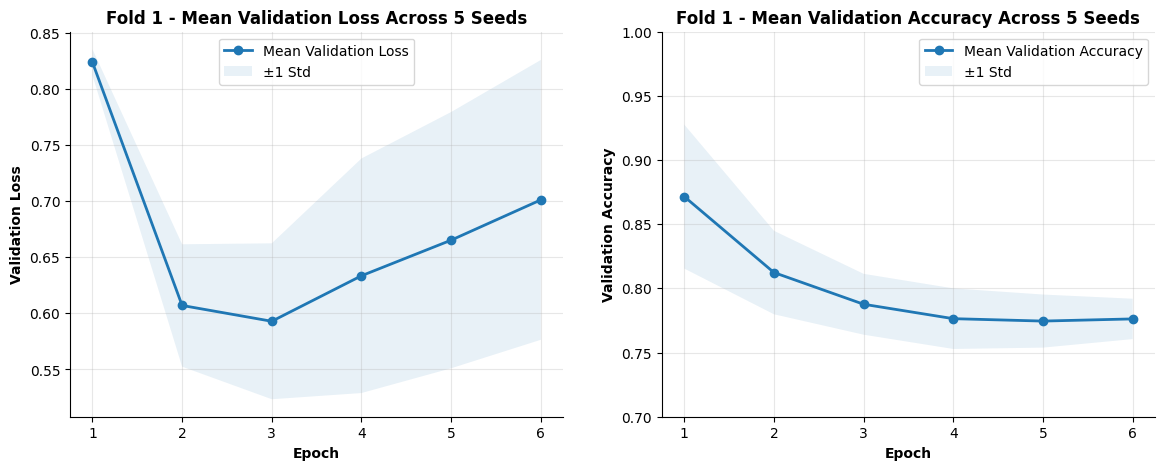

Plotting fold 2


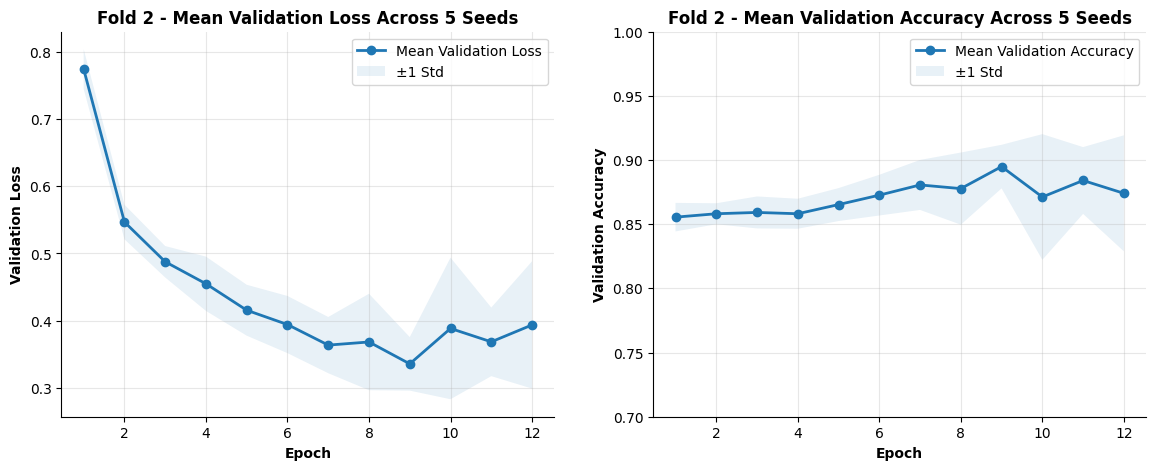

Plotting fold 3


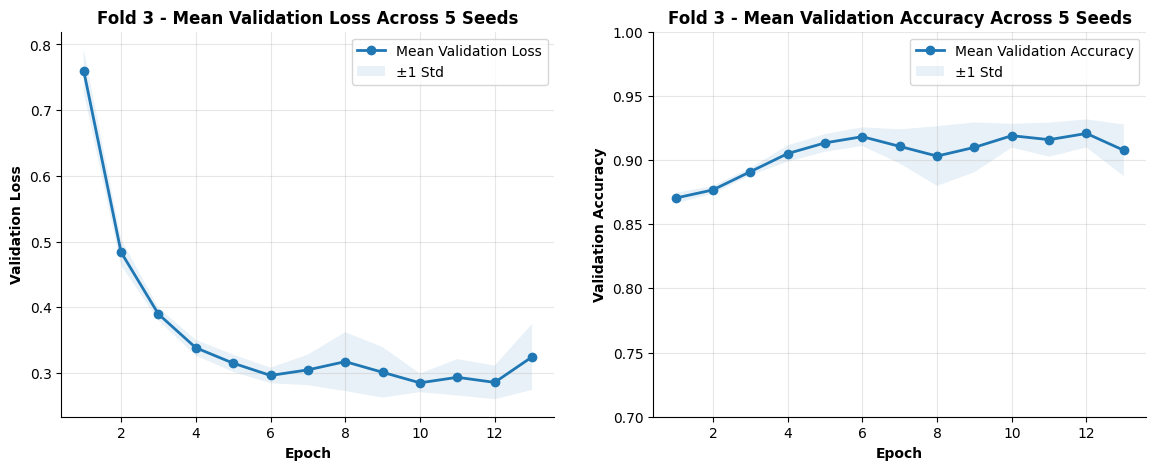

Plotting fold 4


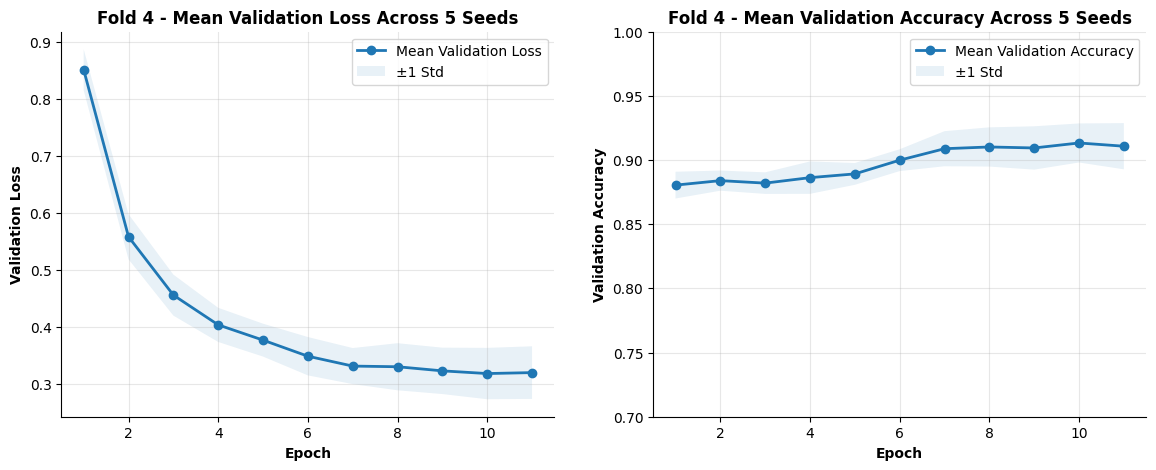

In [11]:
base_dir = "/home/kmercad/mamba_har/Mamba_Baseline_PAM/results_json"
dataset_name = "PAM"

all_folds = load_folds_results(base_dir, dataset_name)
plot_all_folds_val_curves(all_folds)

In [13]:
overall_mean_f1, overall_std_f1, overall_mean_cm = summarize_test_results(all_folds)
print(f"\nOverall mean test_f1 across 4 folds: {overall_mean_f1:.4f} ± {overall_std_f1:.4f}")
print("Overall mean confusion matrix across 4 folds:")
print(np.round(overall_mean_cm, 2))


Overall mean test_f1 across 4 folds: 0.8072 ± 0.0130
Overall mean confusion matrix across 4 folds:
[[223.7    3.65   8.55   6.1 ]
 [  6.05 175.05  72.7    1.7 ]
 [  0.35  57.15 153.95  25.55]
 [  0.     1.85   3.9  291.5 ]]


## SPLIT 1

In [2]:
training_files, validation_files, test_files = data_split_PAM(1)

In [3]:
X_windows, y_windows, X_validation_windows, y_validation_windows, X_test_windows, y_test_windows = load_PAM_loco_data(training_files, validation_files, test_files, verbose = False)

--------------------STRATIY VAL/TEST--------------------
Validation GROUPS
group_id
102    103884
104    105177
Name: count, dtype: int64
Test GROUPS
group_id
101     94637
103    100374
Name: count, dtype: int64 


 Validation Split Label Proportion
27
1.0    0.222313
2.0    0.228818
3.0    0.240514
4.0    0.308355
Name: proportion, dtype: float64
Test Split Label Proportion
27
1.0    0.252452
2.0    0.267887
3.0    0.216654
4.0    0.263006
Name: proportion, dtype: float64

TRAIN
num_windows: 914
mean purity: 0.9963
median purity: 1.0000
fraction < 0.60: 0.0033
fraction < 0.70: 0.0044
fraction < 0.80: 0.0088
fraction < 0.90: 0.0109

TRAIN
num_windows: 841
mean purity: 0.9960
median purity: 1.0000
fraction < 0.60: 0.0024
fraction < 0.70: 0.0071
fraction < 0.80: 0.0095
fraction < 0.90: 0.0119

TRAIN
num_windows: 850
mean purity: 0.9960
median purity: 1.0000
fraction < 0.60: 0.0035
fraction < 0.70: 0.0059
fraction < 0.80: 0.0094
fraction < 0.90: 0.0118

TRAIN
num_windows: 906
mean purity

In [4]:
print(X_windows.shape)
print(X_test_windows.shape)

(3511, 171, 27)
(1702, 171, 27)


In [23]:
def flatten_window(X):
    return X.reshape(X.shape[0], -1)

In [11]:
#LABELS PAM: LIE, SIT, STAND, WALK

X_train = flatten_window(X_windows)
train_sit = X_train[y_windows == 2]
train_stand = X_train[y_windows == 3]

X_test = flatten_window(X_test_windows)
test_sit = X_test[y_test_windows == 2]
test_stand = X_test[y_test_windows == 3]

centroid_train_sit = train_sit.mean(axis = 0)
centroid_train_stand = train_stand.mean(axis = 0)
centroid_test_sit = test_sit.mean(axis = 0)
centroid_test_stand = test_stand.mean(axis = 0)

d_train = np.linalg.norm(centroid_train_sit - centroid_train_stand)
d_test  = np.linalg.norm(centroid_test_sit - centroid_test_stand)

print("Train SIT-STAND centroid distance:", d_train)
print("Test  SIT-STAND centroid distance:", d_test)

Train SIT-STAND centroid distance: 15.667043
Test  SIT-STAND centroid distance: 18.275839


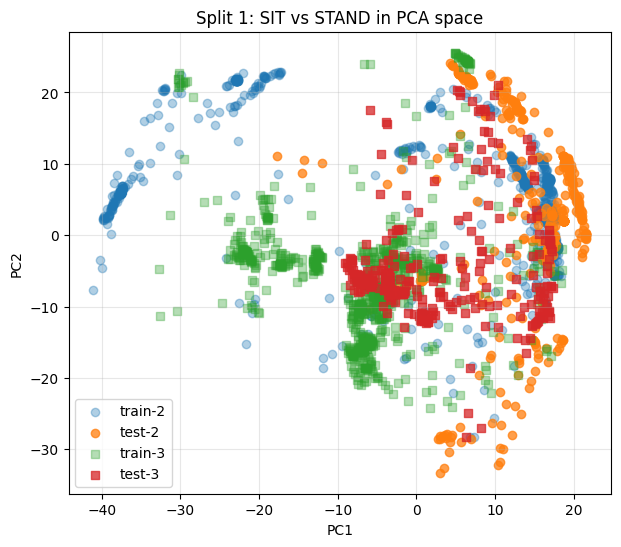

In [16]:
mask_train = np.isin(y_windows, [2, 3])
mask_test = np.isin(y_test_windows, [2, 3])

X_plot = np.vstack([X_train[mask_train], X_test[mask_test]])
y_plot = np.concatenate([y_windows[mask_train], y_test_windows[mask_test]])

split_plot = np.array(["train"] * mask_train.sum() + ["test"] * mask_test.sum())

pca = PCA(n_components=2)
Z = pca.fit_transform(X_plot)

plt.figure(figsize=(7,6))
for cls, marker in [(2, "o"), (3, "s")]:
    for split, alpha in [("train", 0.35), ("test", 0.75)]:
        idx = (y_plot == cls) & (split_plot == split)
        plt.scatter(Z[idx, 0], Z[idx, 1], label=f"{split}-{cls}", alpha=alpha, marker=marker)
I have a
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Split 1: SIT vs STAND in PCA space")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [20]:
training_files, validation_files, test_files = data_split_PAM(4)

In [21]:
X_windows, y_windows, X_validation_windows, y_validation_windows, X_test_windows, y_test_windows = load_PAM_loco_data(training_files, validation_files, test_files, verbose = False)

--------------------STRATIY VAL/TEST--------------------
Validation GROUPS
group_id
104    105177
106     96334
Name: count, dtype: int64
Test GROUPS
group_id
103    100374
105    104690
Name: count, dtype: int64 


 Validation Split Label Proportion
27
1.0    0.230196
2.0    0.240404
3.0    0.243297
4.0    0.286103
Name: proportion, dtype: float64
Test Split Label Proportion
27
1.0    0.223067
2.0    0.271071
3.0    0.208057
4.0    0.297805
Name: proportion, dtype: float64


In [24]:
#LABELS PAM: LIE, SIT, STAND, WALK

X_train = flatten_window(X_windows)
train_sit = X_train[y_windows == 2]
train_stand = X_train[y_windows == 3]

X_test = flatten_window(X_test_windows)
test_sit = X_test[y_test_windows == 2]
test_stand = X_test[y_test_windows == 3]

centroid_train_sit = train_sit.mean(axis = 0)
centroid_train_stand = train_stand.mean(axis = 0)
centroid_test_sit = test_sit.mean(axis = 0)
centroid_test_stand = test_stand.mean(axis = 0)

d_train = np.linalg.norm(centroid_train_sit - centroid_train_stand)
d_test  = np.linalg.norm(centroid_test_sit - centroid_test_stand)

print("Train SIT-STAND centroid distance:", d_train)
print("Test  SIT-STAND centroid distance:", d_test)

Train SIT-STAND centroid distance: 16.998926
Test  SIT-STAND centroid distance: 17.719534


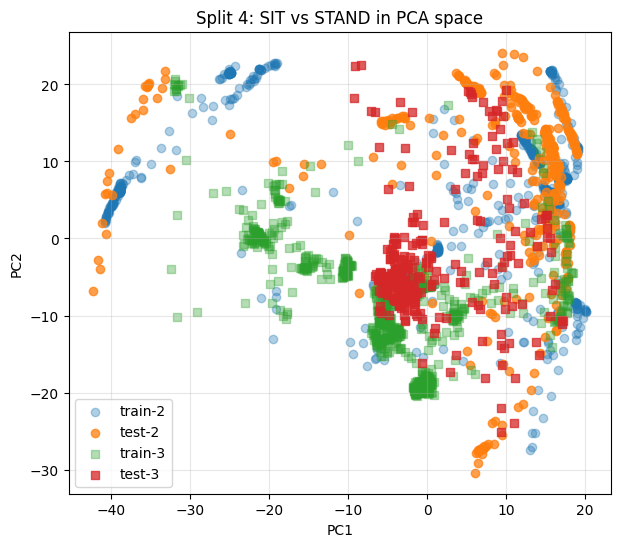

In [27]:
mask_train = np.isin(y_windows, [2, 3])
mask_test = np.isin(y_test_windows, [2, 3])

X_plot = np.vstack([X_train[mask_train], X_test[mask_test]])
y_plot = np.concatenate([y_windows[mask_train], y_test_windows[mask_test]])

split_plot = np.array(["train"] * mask_train.sum() + ["test"] * mask_test.sum())

pca = PCA(n_components=2)
Z = pca.fit_transform(X_plot)

plt.figure(figsize=(7,6))
for cls, marker in [(2, "o"), (3, "s")]:
    for split, alpha in [("train", 0.35), ("test", 0.75)]:
        idx = (y_plot == cls) & (split_plot == split)
        plt.scatter(Z[idx, 0], Z[idx, 1], label=f"{split}-{cls}", alpha=alpha, marker=marker)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Split 4: SIT vs STAND in PCA space")
plt.legend()
plt.grid(alpha=0.3)
plt.show()